# NB01 — Data Loading & Glucoiberin Pathway Exploration

**Goal**: Load transcriptomics and metabolomics data for *Arabidopsis thaliana* Col-0 leaf tissue,
then characterize the glucoiberin biosynthetic pathway as a proof-of-concept for
transcript–metabolite linear modeling.

**Outputs**:
- Diurnal profile of glucoiberin with per-timepoint variance assessment
- Expression profiles and variance for each enzyme in the 9-step glucoiberin pathway
- Assessment of data quality and suitability for linear modeling

In [1]:
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

PROJECT = Path("..")
USER_DATA = PROJECT / "user_data"
FIGURES = PROJECT / "figures"
DATA = PROJECT / "data"
DATA.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

## 1. Load Transcriptomics Data

In [2]:
norm_counts = pd.read_csv(
    USER_DATA / "data" / "col0.leaf" / "norm.counts.csv",
    index_col=0,
)
norm_counts.index = norm_counts.index.str.strip('"')
norm_counts.columns = norm_counts.columns.str.strip('"')

print(f"Transcriptome: {norm_counts.shape[0]} genes × {norm_counts.shape[1]} samples")
print(f"Samples: {sorted(norm_counts.columns.tolist())}")
print(f"\nTimepoints and replicates:")
for zt in sorted(set(c.split('.')[0] for c in norm_counts.columns)):
    cols = [c for c in norm_counts.columns if c.startswith(zt + '.')]
    print(f"  {zt}: {len(cols)} replicates")

Transcriptome: 14257 genes × 32 samples
Samples: ['ZT00.1', 'ZT00.2', 'ZT00.3', 'ZT00.4', 'ZT04.1', 'ZT04.2', 'ZT04.3', 'ZT04.4', 'ZT08.1', 'ZT08.2', 'ZT08.3', 'ZT08.4', 'ZT12.1', 'ZT12.2', 'ZT12.3', 'ZT12.4', 'ZT16.1', 'ZT16.2', 'ZT16.3', 'ZT16.4', 'ZT20.1', 'ZT20.2', 'ZT20.3', 'ZT20.4', 'ZT24.1', 'ZT24.2', 'ZT24.3', 'ZT24.4', 'ZT28.1', 'ZT28.2', 'ZT28.3', 'ZT28.4']

Timepoints and replicates:
  ZT00: 4 replicates
  ZT04: 4 replicates
  ZT08: 4 replicates
  ZT12: 4 replicates
  ZT16: 4 replicates
  ZT20: 4 replicates
  ZT24: 4 replicates
  ZT28: 4 replicates


## 2. Load Metabolomics Data

In [3]:
metabolites = pd.read_csv(
    USER_DATA / "data" / "col0.leaf" / "metabolites.tsv",
    sep="\t",
    index_col=0,
)
print(f"Metabolites: {metabolites.shape[0]} compounds × {metabolites.shape[1]} samples")
print(f"Sample columns match transcriptome: {sorted(metabolites.columns.tolist()) == sorted(norm_counts.columns.tolist())}")

Metabolites: 147 compounds × 32 samples
Sample columns match transcriptome: True


## 3. Load Glucoiberin Pathway Model

In [4]:
with open(USER_DATA / "data" / "glucoiberin" / "glucoiberin-biosynthesis.json") as f:
    gluc_model = json.load(f)

with open(USER_DATA / "athaliana-model-260323.json") as f:
    full_model = json.load(f)

cpd_names = {c["id"]: c.get("name", c["id"]) for c in full_model["modelcompounds"]}
cpd_names.update({c["id"]: c.get("name", c["id"]) for c in gluc_model["modelcompounds"]})

print(f"Glucoiberin submodel: {len(gluc_model['modelreactions'])} reactions, "
      f"{len(gluc_model['modelcompounds'])} compounds")
print(f"Full A. thaliana model: {len(full_model['modelreactions'])} reactions, "
      f"{len(full_model['modelcompounds'])} compounds")

Glucoiberin submodel: 26 reactions, 42 compounds
Full A. thaliana model: 1218 reactions, 1313 compounds


In [5]:
PATHWAY_STEPS = [
    {
        "step": 1,
        "rxn": "rxn13984_c0",
        "name": "CYP79F1/F2",
        "description": "Homomethionine → Aldoxime",
        "substrate": "cpd17403_c0",
        "product": "cpd17431_c0",
        "genes": ["AT1G16410"],
    },
    {
        "step": 2,
        "rxn": "rxn21796_c0",
        "name": "CYP83A1",
        "description": "Aldoxime → Nitrile oxide",
        "substrate": "cpd17431_c0",
        "product": "cpd23389_c0",
        "genes": ["AT4G13770"],
    },
    {
        "step": 3,
        "rxn": "rxn21811_c0",
        "name": "GST",
        "description": "Nitrile oxide → GSH conjugate",
        "substrate": "cpd23389_c0",
        "product": "cpd23390_c0",
        "genes": ["AT1G27130", "AT1G78370", "AT2G30860", "AT2G30870", "AT3G03190"],
    },
    {
        "step": 4,
        "rxn": "rxn21819_c0",
        "name": "GGP",
        "description": "GSH conjugate → Cys-Gly conjugate",
        "substrate": "cpd23390_c0",
        "product": "cpd23391_c0",
        "genes": ["AT2G23960", "AT2G23970", "AT4G29210", "AT4G30530", "AT4G30540", "AT4G30550"],
    },
    {
        "step": 5,
        "rxn": "rxn43940_c0",
        "name": "(unknown)",
        "description": "Cys-Gly → Cys conjugate",
        "substrate": "cpd23391_c0",
        "product": "cpd24789_c0",
        "genes": [],
    },
    {
        "step": 6,
        "rxn": "rxn24582_c0",
        "name": "SUR1 (C-S lyase)",
        "description": "Cys conjugate → Thiohydroximate",
        "substrate": "cpd24789_c0",
        "product": "cpd17433_c0",
        "genes": ["AT2G20610"],
    },
    {
        "step": 7,
        "rxn": "rxn14074_c0",
        "name": "UGT74B1",
        "description": "Thiohydroximate → Desulfoglucosinolate",
        "substrate": "cpd17433_c0",
        "product": "cpd17434_c0",
        "genes": ["AT1G24100"],
    },
    {
        "step": 8,
        "rxn": "rxn14133_c0",
        "name": "SOT",
        "description": "Desulfoglucosinolate → Glucoiberverin",
        "substrate": "cpd17434_c0",
        "product": "cpd05324_c0",
        "genes": ["AT1G18590", "AT1G74090"],
    },
    {
        "step": 9,
        "rxn": "rxn41751_c0",
        "name": "FMOGS-OX",
        "description": "Glucoiberverin → Glucoiberin",
        "substrate": "cpd05324_c0",
        "product": "cpd05323_c0",
        "genes": ["AT1G12140", "AT1G62540", "AT1G62560", "AT1G62570", "AT1G65860"],
    },
]

all_pathway_genes = []
for step in PATHWAY_STEPS:
    all_pathway_genes.extend(step["genes"])
all_pathway_genes = sorted(set(all_pathway_genes))

in_tx = [g for g in all_pathway_genes if g in norm_counts.index]
missing = [g for g in all_pathway_genes if g not in norm_counts.index]
print(f"Pathway genes: {len(all_pathway_genes)} unique")
print(f"In transcriptome: {len(in_tx)}")
print(f"Missing: {missing}")

print("\nPathway overview:")
for s in PATHWAY_STEPS:
    genes_str = ", ".join(s["genes"]) if s["genes"] else "(no gene)"
    in_data = sum(1 for g in s["genes"] if g in norm_counts.index)
    print(f"  Step {s['step']}: {s['name']:15s} {s['description']:45s} genes: {genes_str} [{in_data}/{len(s['genes'])} in data]")

Pathway genes: 22 unique
In transcriptome: 18
Missing: ['AT2G23960', 'AT2G23970', 'AT3G03190', 'AT4G30540']

Pathway overview:
  Step 1: CYP79F1/F2      Homomethionine → Aldoxime                     genes: AT1G16410 [1/1 in data]
  Step 2: CYP83A1         Aldoxime → Nitrile oxide                      genes: AT4G13770 [1/1 in data]
  Step 3: GST             Nitrile oxide → GSH conjugate                 genes: AT1G27130, AT1G78370, AT2G30860, AT2G30870, AT3G03190 [4/5 in data]
  Step 4: GGP             GSH conjugate → Cys-Gly conjugate             genes: AT2G23960, AT2G23970, AT4G29210, AT4G30530, AT4G30540, AT4G30550 [3/6 in data]
  Step 5: (unknown)       Cys-Gly → Cys conjugate                       genes: (no gene) [0/0 in data]
  Step 6: SUR1 (C-S lyase) Cys conjugate → Thiohydroximate               genes: AT2G20610 [1/1 in data]
  Step 7: UGT74B1         Thiohydroximate → Desulfoglucosinolate        genes: AT1G24100 [1/1 in data]
  Step 8: SOT             Desulfoglucosinolate → Glu

## 4. Load Glucoiberin Intensity from JGI Metabolomics

In [6]:
ph_file = (
    USER_DATA / "Targeted"
    / "JGI-HILIC_20250321_JGI_KG_510479_Brassica_final-set2_EXP120B_HILICZ_USHXG01827"
    / "EMA-NEG" / "NEG_data_sheets" / "NEG_peak_height.tab"
)

with open(ph_file) as f:
    reader = csv.reader(f, delimiter="\t")
    rows = list(reader)

sample_treatments = rows[3]

col0_leaf_zt = {}
for i in range(1, len(sample_treatments)):
    st = sample_treatments[i]
    if "COL0-L" in st:
        zt_num = int(st.split("-")[0].replace("ZT", ""))
        if zt_num not in col0_leaf_zt:
            col0_leaf_zt[zt_num] = []
        col0_leaf_zt[zt_num].append(i)

glucoiberin_row = None
for row in rows[6:]:
    if "Glucoiberin" in row[0]:
        glucoiberin_row = row
        break

gluc_zt_data = {}
for zt_num in sorted(col0_leaf_zt.keys()):
    vals = []
    for ci in col0_leaf_zt[zt_num]:
        v = glucoiberin_row[ci]
        if v and v.strip():
            vals.append(float(v))
    gluc_zt_data[zt_num] = np.array(vals)

print("Glucoiberin per-timepoint (COL0 leaf):")
for zt in sorted(gluc_zt_data.keys()):
    arr = gluc_zt_data[zt]
    mean = np.mean(arr)
    std = np.std(arr, ddof=1) if len(arr) > 1 else 0
    cv = std / mean * 100 if mean > 0 else 0
    print(f"  ZT{zt:02d}: n={len(arr)}, mean={mean:.0f}, CV={cv:.1f}%")

Glucoiberin per-timepoint (COL0 leaf):
  ZT00: n=4, mean=4565985, CV=19.1%
  ZT04: n=4, mean=7188967, CV=69.1%
  ZT08: n=4, mean=13022980, CV=25.4%
  ZT12: n=4, mean=6451556, CV=67.2%
  ZT16: n=4, mean=5560882, CV=40.6%
  ZT20: n=4, mean=58919670, CV=18.9%
  ZT24: n=4, mean=63565176, CV=3.4%
  ZT28: n=4, mean=51860384, CV=65.8%


## 5. Glucoiberin Diurnal Profile & Variance

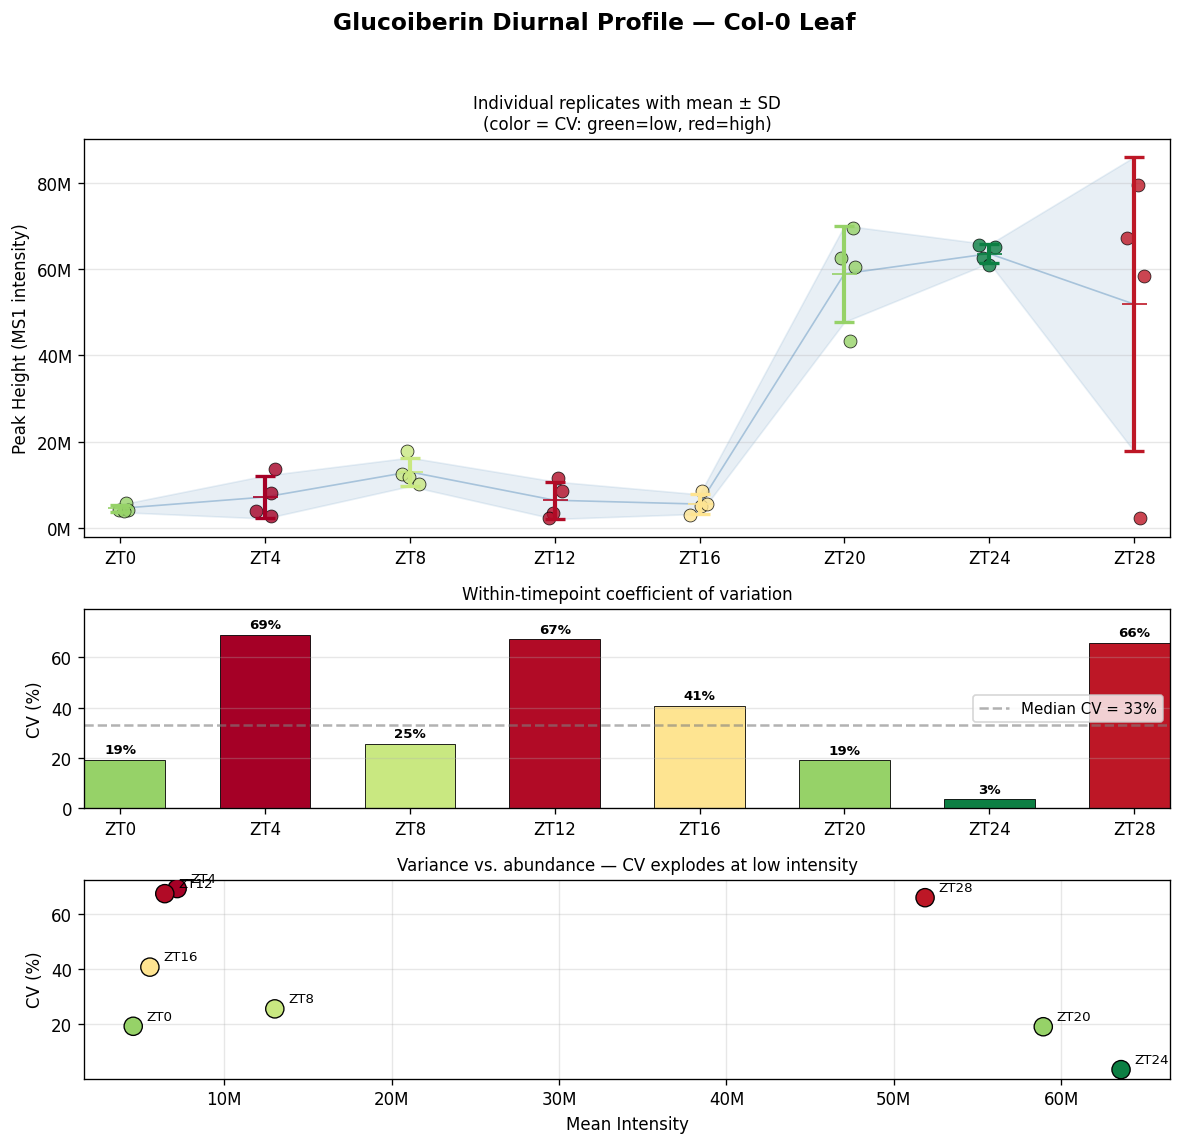

Saved: figures/glucoiberin_diurnal_variance.png


In [7]:
zts = sorted(gluc_zt_data.keys())
means = np.array([np.mean(gluc_zt_data[z]) for z in zts])
stds = np.array([np.std(gluc_zt_data[z], ddof=1) if len(gluc_zt_data[z]) > 1 else 0 for z in zts])
cvs = np.array([(stds[i] / means[i] * 100) if means[i] > 0 else 0 for i in range(len(zts))])
cv_norm = cvs / cvs.max()
cmap = plt.cm.RdYlGn_r

fig, axes = plt.subplots(3, 1, figsize=(10, 10), gridspec_kw={"height_ratios": [3, 1.5, 1.5]})
fig.suptitle("Glucoiberin Diurnal Profile — Col-0 Leaf", fontsize=14, fontweight="bold", y=0.95)

ax1 = axes[0]
rng = np.random.default_rng(42)
for i, zt_num in enumerate(zts):
    vals = gluc_zt_data[zt_num]
    jitter = rng.uniform(-0.3, 0.3, len(vals))
    color = cmap(cv_norm[i])
    ax1.scatter(
        [zt_num + j for j in jitter], vals,
        color=color, s=60, alpha=0.8, edgecolors="k", linewidths=0.5, zorder=3,
    )
    ax1.errorbar(
        zt_num, means[i], yerr=stds[i], fmt="_", markersize=15,
        color=color, ecolor=color, elinewidth=2.5, capsize=6, capthick=2, zorder=4,
    )
ax1.fill_between(zts, means - stds, means + stds, alpha=0.12, color="steelblue")
ax1.plot(zts, means, "-", color="steelblue", alpha=0.4, linewidth=1)
ax1.set_ylabel("Peak Height (MS1 intensity)")
ax1.set_xticks(zts)
ax1.set_xticklabels([f"ZT{z}" for z in zts])
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M"))
ax1.set_xlim(-1, 29)
ax1.grid(axis="y", alpha=0.3)
ax1.set_title("Individual replicates with mean ± SD\n(color = CV: green=low, red=high)", fontsize=10)

ax2 = axes[1]
ax2.bar(zts, cvs, width=2.5, color=[cmap(c) for c in cv_norm], edgecolor="k", linewidth=0.5)
ax2.axhline(y=np.median(cvs), color="gray", linestyle="--", alpha=0.6, label=f"Median CV = {np.median(cvs):.0f}%")
ax2.set_ylabel("CV (%)")
ax2.set_xticks(zts)
ax2.set_xticklabels([f"ZT{z}" for z in zts])
ax2.set_xlim(-1, 29)
ax2.set_ylim(0, max(cvs) * 1.15)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.set_title("Within-timepoint coefficient of variation", fontsize=10)
for i, (zt_num, cv) in enumerate(zip(zts, cvs)):
    ax2.text(zt_num, cv + 1.5, f"{cv:.0f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax3 = axes[2]
ax3.scatter(means, cvs, c=[cmap(c) for c in cv_norm], s=120, edgecolors="k", linewidths=0.8, zorder=3)
for i, zt_num in enumerate(zts):
    ax3.annotate(f"ZT{zt_num}", (means[i], cvs[i]), textcoords="offset points", xytext=(8, 4), fontsize=8)
ax3.set_xlabel("Mean Intensity")
ax3.set_ylabel("CV (%)")
ax3.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M"))
ax3.grid(alpha=0.3)
ax3.set_title("Variance vs. abundance — CV explodes at low intensity", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIGURES / "glucoiberin_diurnal_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/glucoiberin_diurnal_variance.png")

## 6. Glucoiberin Pathway Enzyme Expression Profiles

For each of the 9 biosynthetic steps, plot the diurnal expression profile
of every gene, with within-timepoint variance colored by CV.
Steps are ordered from substrate (homomethionine) to product (glucoiberin).

In [8]:
def get_gene_zt_stats(gene_id, counts_df):
    """Extract per-timepoint mean, std, cv for a gene."""
    if gene_id not in counts_df.index:
        return None
    row = counts_df.loc[gene_id]
    zt_map = {}
    for col in row.index:
        zt = int(col.split(".")[0].replace("ZT", ""))
        if zt not in zt_map:
            zt_map[zt] = []
        zt_map[zt].append(row[col])
    result = {}
    for zt in sorted(zt_map.keys()):
        arr = np.array(zt_map[zt])
        mean = np.mean(arr)
        std = np.std(arr, ddof=1) if len(arr) > 1 else 0
        cv = (std / mean * 100) if mean > 0 else 0
        result[zt] = {"values": arr, "mean": mean, "std": std, "cv": cv}
    return result

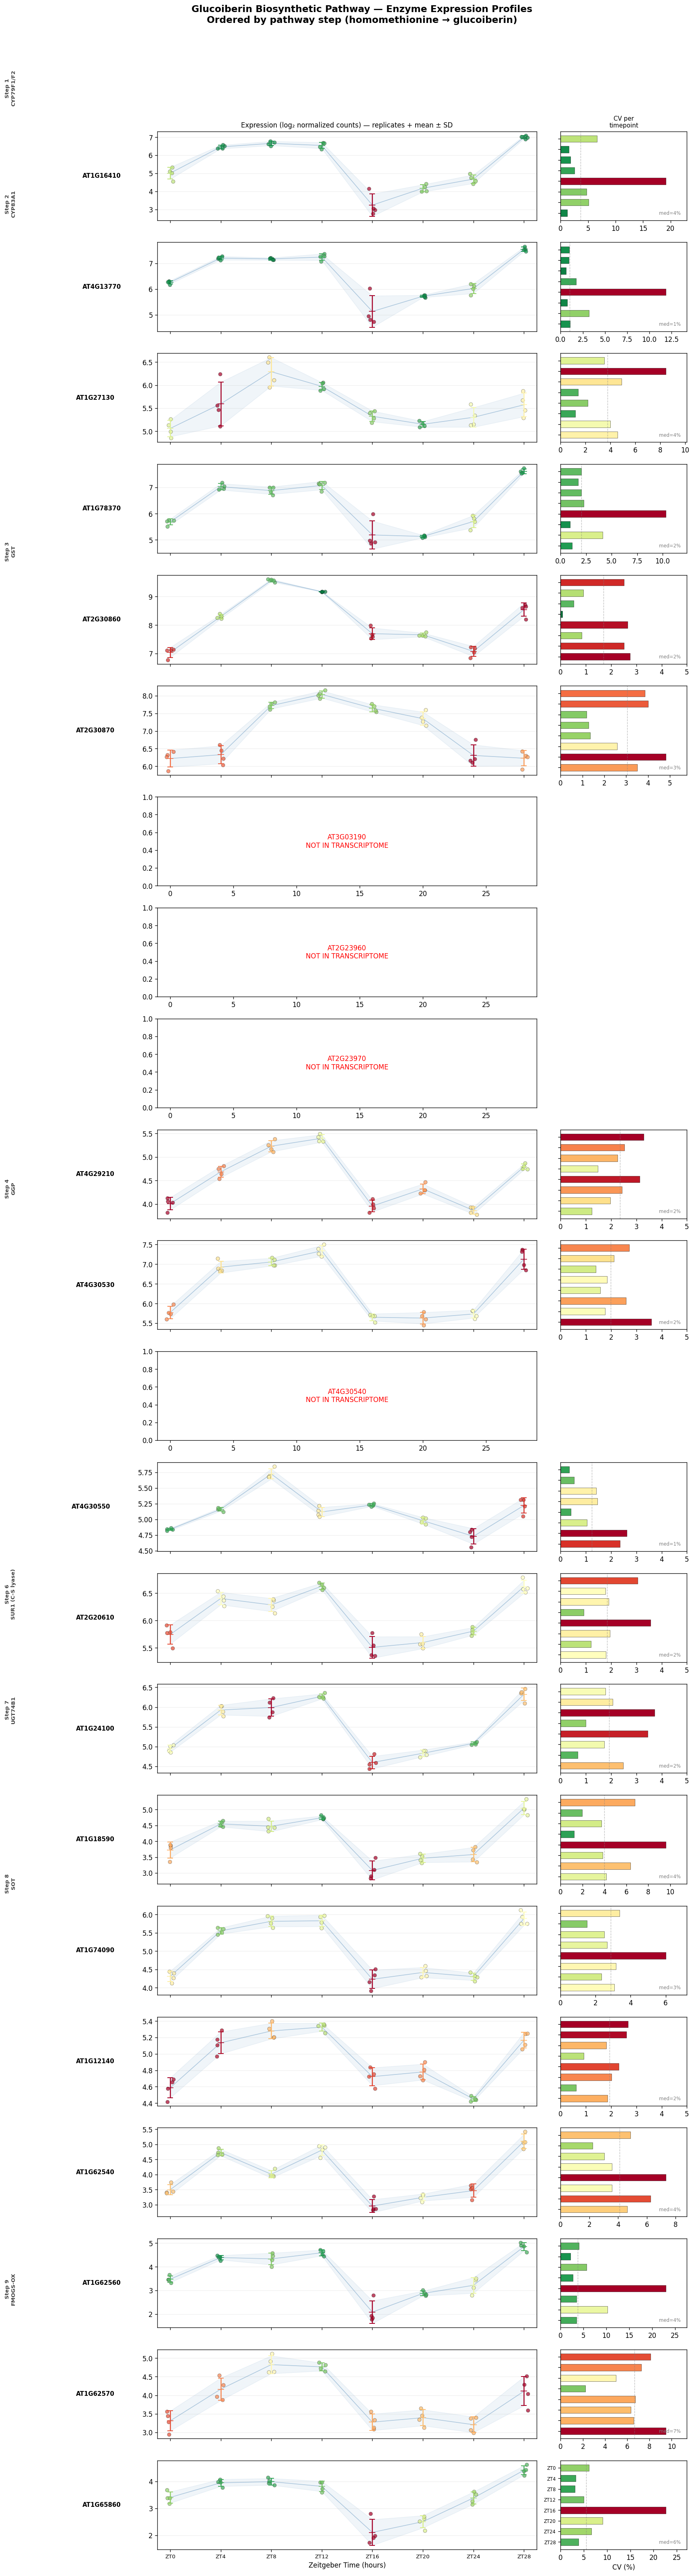

Saved: figures/glucoiberin_pathway_enzyme_profiles.png


In [9]:
steps_with_genes = [s for s in PATHWAY_STEPS if s["genes"]]
total_gene_rows = sum(len(s["genes"]) for s in steps_with_genes)

fig, axes = plt.subplots(
    total_gene_rows, 2,
    figsize=(14, 2.4 * total_gene_rows),
    gridspec_kw={"width_ratios": [3, 1]},
)
if total_gene_rows == 1:
    axes = axes.reshape(1, -1)

fig.suptitle(
    "Glucoiberin Biosynthetic Pathway — Enzyme Expression Profiles\n"
    "Ordered by pathway step (homomethionine → glucoiberin)",
    fontsize=14, fontweight="bold", y=1.01,
)

cmap = plt.cm.RdYlGn_r
rng = np.random.default_rng(42)
row_idx = 0

step_boundaries = []

for step in steps_with_genes:
    step_start = row_idx
    for gene in step["genes"]:
        stats = get_gene_zt_stats(gene, norm_counts)

        ax_profile = axes[row_idx, 0]
        ax_cv = axes[row_idx, 1]

        if stats is None:
            ax_profile.text(
                0.5, 0.5, f"{gene}\nNOT IN TRANSCRIPTOME",
                ha="center", va="center", transform=ax_profile.transAxes,
                fontsize=10, color="red",
            )
            ax_profile.set_xlim(-1, 29)
            ax_cv.set_visible(False)
            row_idx += 1
            continue

        zt_list = sorted(stats.keys())
        gene_means = np.array([stats[z]["mean"] for z in zt_list])
        gene_stds = np.array([stats[z]["std"] for z in zt_list])
        gene_cvs = np.array([stats[z]["cv"] for z in zt_list])
        max_cv = gene_cvs.max() if gene_cvs.max() > 0 else 1
        cv_normed = gene_cvs / max_cv

        for i, zt in enumerate(zt_list):
            vals = stats[zt]["values"]
            jitter = rng.uniform(-0.3, 0.3, len(vals))
            color = cmap(cv_normed[i])
            ax_profile.scatter(
                [zt + j for j in jitter], vals,
                color=color, s=30, alpha=0.7, edgecolors="k", linewidths=0.3, zorder=3,
            )
            ax_profile.errorbar(
                zt, gene_means[i], yerr=gene_stds[i], fmt="_", markersize=10,
                color=color, ecolor=color, elinewidth=1.5, capsize=4, capthick=1.2, zorder=4,
            )

        ax_profile.plot(zt_list, gene_means, "-", color="steelblue", alpha=0.4, linewidth=1)
        ax_profile.fill_between(zt_list, gene_means - gene_stds, gene_means + gene_stds, alpha=0.08, color="steelblue")
        ax_profile.set_xlim(-1, 29)
        ax_profile.set_xticks(zt_list)
        if row_idx == total_gene_rows - 1:
            ax_profile.set_xticklabels([f"ZT{z}" for z in zt_list], fontsize=8)
        else:
            ax_profile.set_xticklabels([])
        ax_profile.set_ylabel(f"{gene}", fontsize=9, fontweight="bold", rotation=0, labelpad=70, va="center")
        ax_profile.grid(axis="y", alpha=0.2)

        median_cv = np.median(gene_cvs)
        ax_cv.barh(
            zt_list, gene_cvs, height=2.5,
            color=[cmap(c) for c in cv_normed], edgecolor="k", linewidth=0.3,
        )
        ax_cv.axvline(x=median_cv, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
        ax_cv.set_xlim(0, max(gene_cvs.max() * 1.2, 5))
        ax_cv.set_yticks(zt_list)
        if row_idx == total_gene_rows - 1:
            ax_cv.set_yticklabels([f"ZT{z}" for z in zt_list], fontsize=7)
        else:
            ax_cv.set_yticklabels([])
        ax_cv.set_xlabel("" if row_idx < total_gene_rows - 1 else "CV (%)")
        ax_cv.text(
            0.95, 0.05, f"med={median_cv:.0f}%",
            ha="right", va="bottom", transform=ax_cv.transAxes, fontsize=7, color="gray",
        )
        ax_cv.invert_yaxis()

        row_idx += 1

    step_boundaries.append((step_start, row_idx - 1, step))

for start, end, step in step_boundaries:
    mid = (start + end) / 2
    y_mid = 1 - (mid + 0.5) / total_gene_rows
    fig.text(
        -0.02, y_mid,
        f"Step {step['step']}\n{step['name']}",
        ha="center", va="center", fontsize=8, fontweight="bold",
        rotation=90, color="#444444",
    )

axes[-1, 0].set_xlabel("Zeitgeber Time (hours)")
axes[0, 0].set_title("Expression (log₂ normalized counts) — replicates + mean ± SD", fontsize=10)
axes[0, 1].set_title("CV per\ntimepoint", fontsize=9)

plt.tight_layout(rect=[0.06, 0, 1, 0.98])
plt.savefig(FIGURES / "glucoiberin_pathway_enzyme_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/glucoiberin_pathway_enzyme_profiles.png")

## 7. Pathway Summary — Expression Level and Variance Heatmap

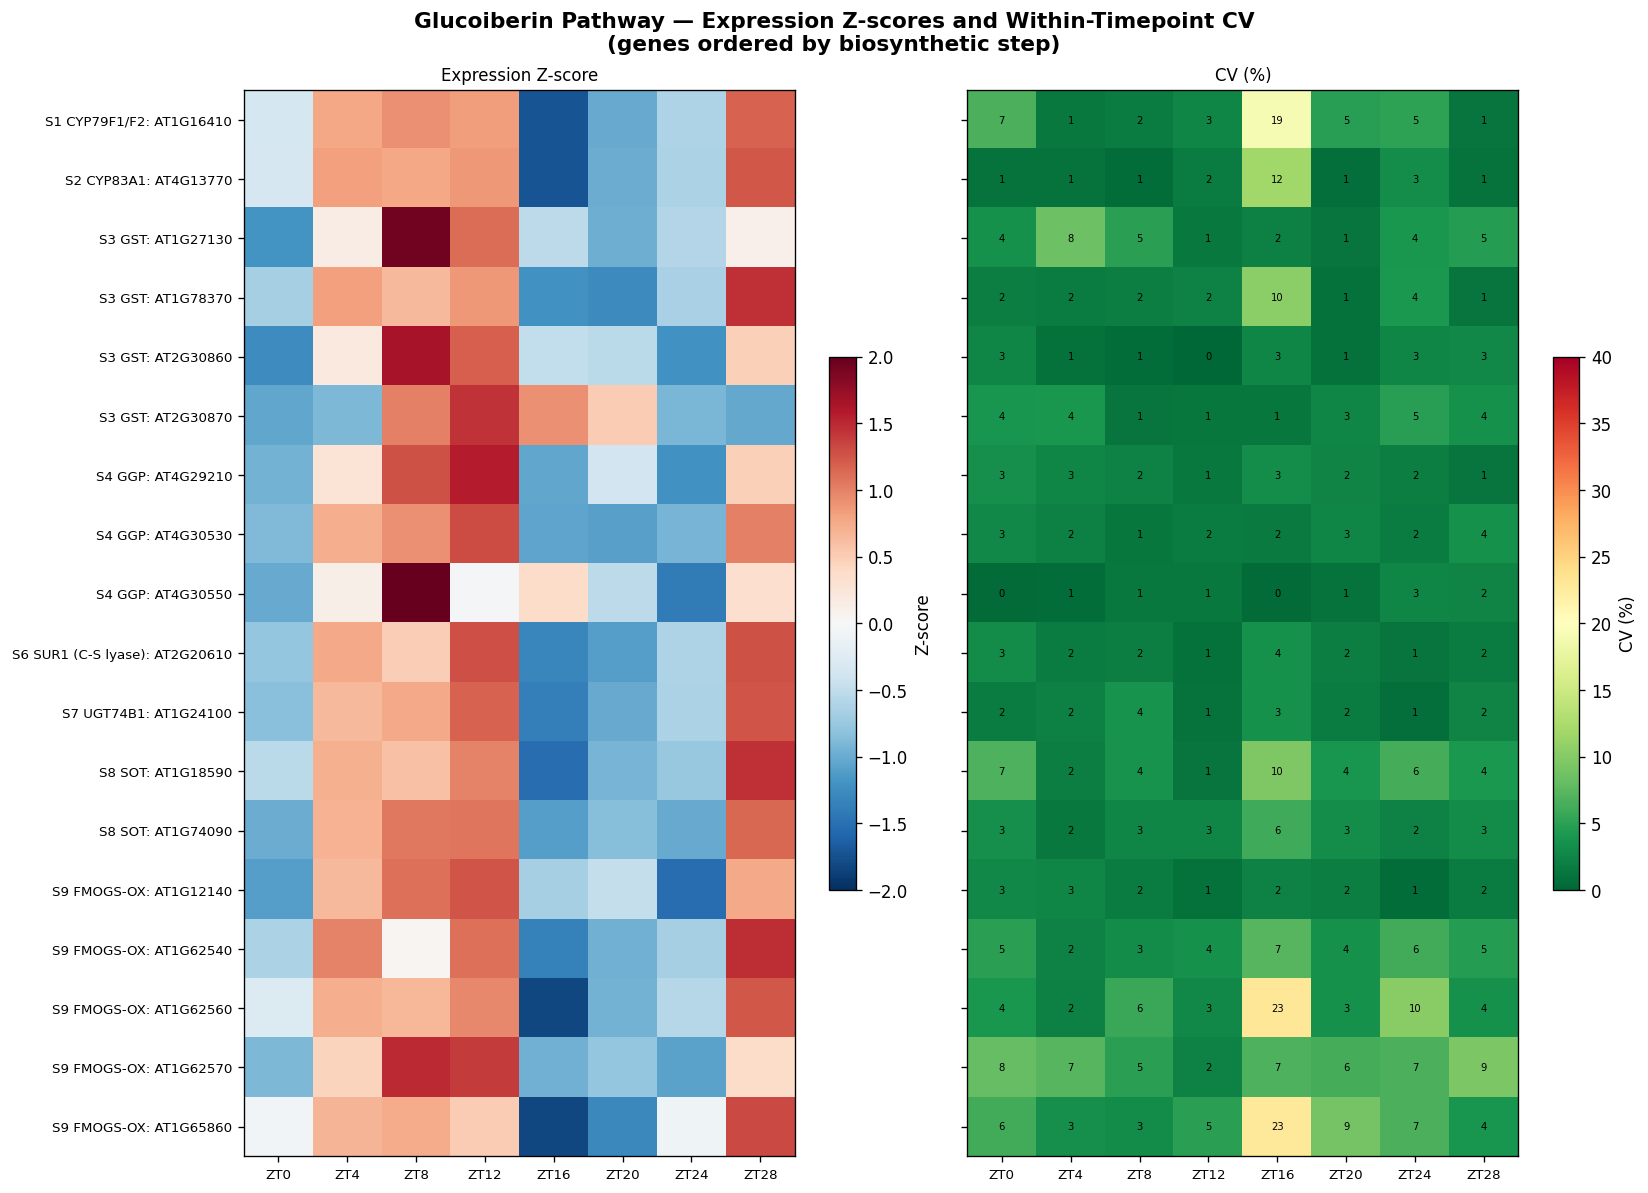

Saved: figures/glucoiberin_pathway_heatmap.png


In [10]:
zt_order = [0, 4, 8, 12, 16, 20, 24, 28]

gene_labels = []
mean_matrix = []
cv_matrix = []

for step in PATHWAY_STEPS:
    for gene in step["genes"]:
        stats = get_gene_zt_stats(gene, norm_counts)
        if stats is None:
            continue
        gene_labels.append(f"S{step['step']} {step['name']}: {gene}")
        mean_matrix.append([stats[z]["mean"] for z in zt_order])
        cv_matrix.append([stats[z]["cv"] for z in zt_order])

mean_arr = np.array(mean_matrix)
cv_arr = np.array(cv_matrix)

mean_zscore = (mean_arr - mean_arr.mean(axis=1, keepdims=True)) / (mean_arr.std(axis=1, keepdims=True) + 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 0.45 * len(gene_labels) + 2), gridspec_kw={"width_ratios": [1, 1]})
fig.suptitle(
    "Glucoiberin Pathway — Expression Z-scores and Within-Timepoint CV\n"
    "(genes ordered by biosynthetic step)",
    fontsize=13, fontweight="bold",
)

im1 = ax1.imshow(mean_zscore, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax1.set_xticks(range(len(zt_order)))
ax1.set_xticklabels([f"ZT{z}" for z in zt_order], fontsize=8)
ax1.set_yticks(range(len(gene_labels)))
ax1.set_yticklabels(gene_labels, fontsize=8)
ax1.set_title("Expression Z-score", fontsize=10)
plt.colorbar(im1, ax=ax1, shrink=0.5, label="Z-score")

im2 = ax2.imshow(cv_arr, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=40)
ax2.set_xticks(range(len(zt_order)))
ax2.set_xticklabels([f"ZT{z}" for z in zt_order], fontsize=8)
ax2.set_yticks(range(len(gene_labels)))
ax2.set_yticklabels([], fontsize=8)
ax2.set_title("CV (%)", fontsize=10)
cb2 = plt.colorbar(im2, ax=ax2, shrink=0.5, label="CV (%)")

for i in range(cv_arr.shape[0]):
    for j in range(cv_arr.shape[1]):
        ax2.text(j, i, f"{cv_arr[i, j]:.0f}", ha="center", va="center", fontsize=6,
                 color="white" if cv_arr[i, j] > 25 else "black")

plt.tight_layout()
plt.savefig(FIGURES / "glucoiberin_pathway_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/glucoiberin_pathway_heatmap.png")

## 8. Pathway Enzyme Reliability Summary Table

In [11]:
summary_rows = []
for step in PATHWAY_STEPS:
    for gene in step["genes"]:
        stats = get_gene_zt_stats(gene, norm_counts)
        if stats is None:
            summary_rows.append({
                "Step": step["step"],
                "Enzyme": step["name"],
                "Gene": gene,
                "In Data": False,
                "Median CV": np.nan,
                "Mean Expr": np.nan,
                "Dynamic Range": np.nan,
            })
            continue
        zt_list = sorted(stats.keys())
        cvs = [stats[z]["cv"] for z in zt_list]
        means = [stats[z]["mean"] for z in zt_list]
        dr = max(means) / min(means) if min(means) > 0 else np.nan
        summary_rows.append({
            "Step": step["step"],
            "Enzyme": step["name"],
            "Gene": gene,
            "In Data": True,
            "Median CV": np.median(cvs),
            "Mean Expr": np.mean(means),
            "Dynamic Range": dr,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df["Median CV"] = summary_df["Median CV"].round(1)
summary_df["Mean Expr"] = summary_df["Mean Expr"].round(2)
summary_df["Dynamic Range"] = summary_df["Dynamic Range"].round(1)
print(summary_df.to_string(index=False))

summary_df.to_csv(DATA / "glucoiberin_pathway_enzyme_summary.csv", index=False)
print("\nSaved: data/glucoiberin_pathway_enzyme_summary.csv")

 Step           Enzyme      Gene  In Data  Median CV  Mean Expr  Dynamic Range
    1       CYP79F1/F2 AT1G16410     True        3.7       5.47            2.2
    2          CYP83A1 AT4G13770     True        1.0       6.54            1.5
    3              GST AT1G27130     True        3.8       5.53            1.2
    3              GST AT1G78370     True        2.0       6.29            1.5
    3              GST AT2G30860     True        1.7       8.13            1.4
    3              GST AT2G30870     True        3.0       6.98            1.3
    3              GST AT3G03190    False        NaN        NaN            NaN
    4              GGP AT2G23960    False        NaN        NaN            NaN
    4              GGP AT2G23970    False        NaN        NaN            NaN
    4              GGP AT4G29210     True        2.3       4.53            1.4
    4              GGP AT4G30530     True        2.0       6.41            1.3
    4              GGP AT4G30540    False        NaN

## 9. Key Observations

Summary of findings will be filled after notebook execution.